<a href="https://colab.research.google.com/github/AryanKumar1416/PRODIGY_DS_03/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path= '/content/drive/MyDrive/Titanic'
df=pd.read_csv(file_path)
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

print("Number of missing values in 'Age' after imputation:", df['Age'].isnull().sum())

Number of missing values in 'Age' after imputation: 0


In [7]:
df.dropna(subset=['Embarked'], inplace=True)
print("Number of missing values in 'Embarked' after dropping rows:", df['Embarked'].isnull().sum())

Number of missing values in 'Embarked' after dropping rows: 0


In [8]:
df.drop('Cabin', axis=1, inplace=True)
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [10]:
print(df.shape)

(889, 11)


In [11]:
df.describe()
df['Sex'].value_counts()


,count
Sex,
male,577
female,312


In [12]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,214
2,184


In [13]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,340


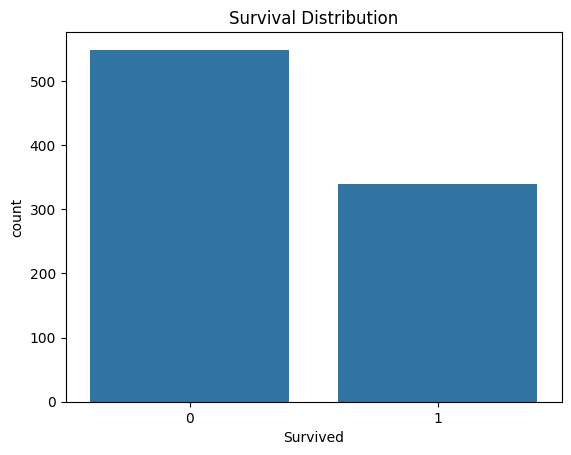

In [14]:
sns.countplot(data=df, x='Survived')
plt.title("Survival Distribution")
plt.show()

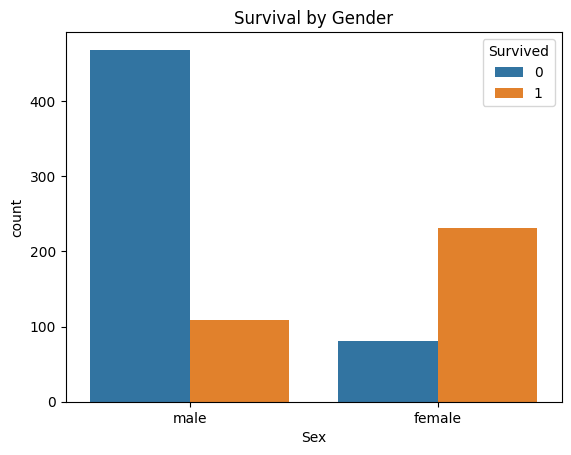

In [15]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival by Gender")
plt.show()

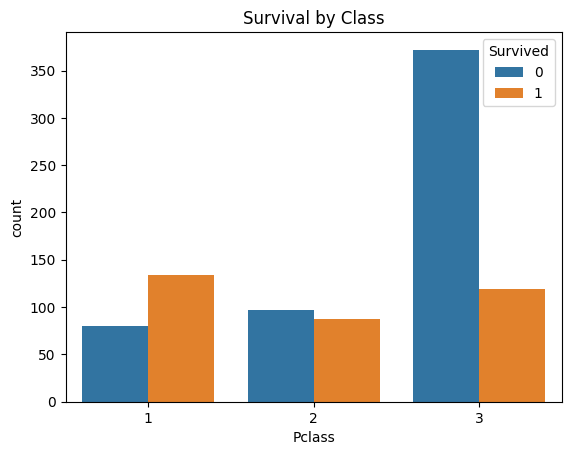

In [16]:
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title("Survival by Class")
plt.show()

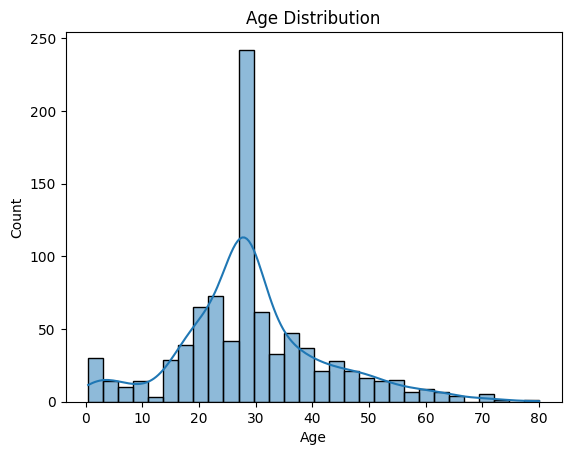

In [17]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

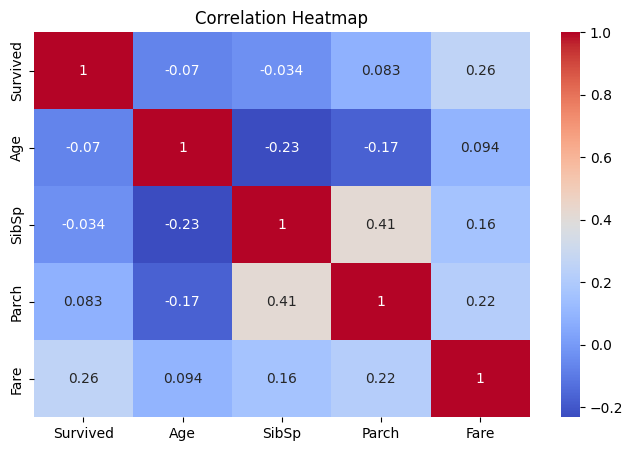

In [18]:
# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[['Survived','Age','SibSp','Parch','Fare']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Heatmap Correlation

* Survived and Pclass: There is a notable negative correlation (-0.34) between 'Survived' and 'Pclass'. This suggests that passengers in lower classes (higher Pclass number) were less likely to survive.

* Survived and Age: The correlation between 'Survived' and 'Age' is weak and slightly negative (-0.065). This suggests that age doesn't have a strong linear relationship with survival on its own, though other factors related to age (like being a child) might be important.

* Survived and SibSp/Parch: The correlations between 'Survived' and 'SibSp' (number of siblings/spouses) and 'Parch' (number of parents/children) are also weak and slightly negative (-0.034 and 0.083 respectively). This suggests that the number of family members on board has a less direct linear relationship with survival compared to Pclass or Fare.

# Task
Explain what more can be done with the Titanic dataset.

## Feature engineering

### Subtask:
Create new features from existing ones that might be more informative for predicting survival.


**Reasoning**:
Create `FamilySize` and `IsAlone` features based on `SibSp` and `Parch` columns.



In [19]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

**Reasoning**:
Extract the title from the 'Name' column and group rare titles into a single category.



In [26]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
display(df['Title'].value_counts())

,count
Title,
Mr,517
Miss,181
Mrs,124
Master,40
Rare,27


## Categorical feature encoding

### Subtask:
Convert categorical variables ('Sex' and 'Embarked') into a numerical format that can be used by machine learning models.


**Reasoning**:
Convert the 'Sex' and 'Embarked' columns into numerical features using one-hot encoding and then concatenate them with the original DataFrame while dropping the original categorical columns.



In [20]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
display(df.head())

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,0,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,0,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,1,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,0,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,1,True,False,True


## Data scaling

### Subtask:
Scale numerical features to ensure they have a similar range, which can improve the performance of some models.


**Reasoning**:
Import StandardScaler and identify numerical columns to scale.



In [21]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']

**Reasoning**:
Instantiate and fit the scaler to the selected numerical columns and transform them, then replace the original columns with the scaled values.



In [22]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
display(df.head())

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.563674,0.431350,-0.474326,A/5 21171,-0.500240,0.057853,0,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.669217,0.431350,-0.474326,PC 17599,0.788947,0.057853,0,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.255451,-0.475199,-0.474326,STON/O2. 3101282,-0.486650,-0.561804,1,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.438050,0.431350,-0.474326,113803,0.422861,0.057853,0,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0.438050,-0.475199,-0.474326,373450,-0.484133,-0.561804,1,True,False,True


## Model selection and training

### Subtask:
Choose a suitable machine learning model, train it on the prepared data, and evaluate its performance.


**Reasoning**:
Split the data into features (X) and target variable (y), then split these into training and testing sets, and finally train and evaluate a Logistic Regression model.



In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X = df.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Title'], axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.8202
Precision: 0.7681
Recall: 0.7681
F1-score: 0.7681


## Summary:

### Data Analysis Key Findings

*   New features `FamilySize` and `IsAlone` were created from existing `SibSp` and `Parch` columns.
*   A `Title` feature was extracted from the `Name` column, with rare titles grouped into a 'Rare' category.
*   Categorical features `Sex` and `Embarked` were successfully converted into numerical format using one-hot encoding.
*   Numerical features `Age`, `SibSp`, `Parch`, `Fare`, and `FamilySize` were scaled using `StandardScaler`.
*   A Logistic Regression model was trained on the prepared data and achieved an accuracy of 0.8202, precision of 0.7681, recall of 0.7681, and an F1-score of 0.7681 on the test set.

### Insights or Next Steps

*   Further model tuning and exploration of other classification algorithms (e.g., Random Forest, Gradient Boosting) could potentially improve prediction performance.
*   Investigating the coefficients of the Logistic Regression model could provide insights into which features are most influential in predicting survival.


Survival Percentage by Sex:
Female: 74.04%
Male: 18.89%


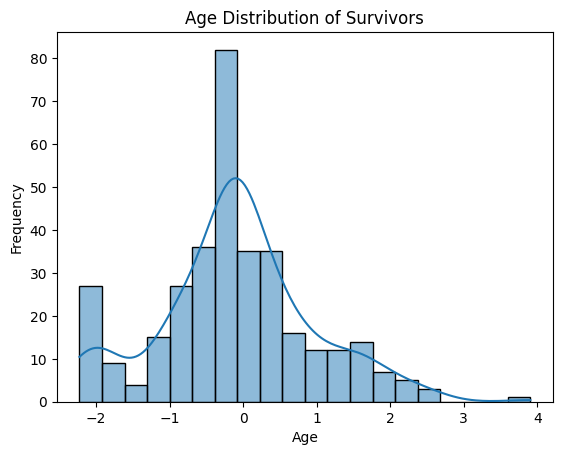


Survival Percentage by Passenger Class:
Class 1: 62.62%
Class 2: 47.28%
Class 3: 24.24%


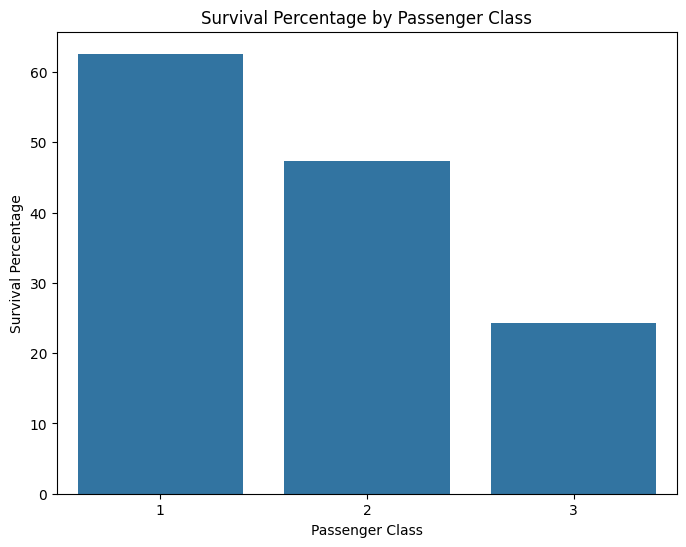

In [29]:
# Calculate survival percentage by sex
survival_by_sex = df.groupby('Sex_male')['Survived'].mean() * 100

print("Survival Percentage by Sex:")
print(f"Female: {survival_by_sex[False]:.2f}%")
print(f"Male: {survival_by_sex[True]:.2f}%")

# Analyze age of survivors
sns.histplot(df[df['Survived'] == 1]['Age'], kde=True)
plt.title("Age Distribution of Survivors")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Analyze role of pclass in survival
survival_by_pclass = df.groupby('Pclass')['Survived'].mean() * 100

print("\nSurvival Percentage by Passenger Class:")
for pclass, percentage in survival_by_pclass.items():
    print(f"Class {pclass}: {percentage:.2f}%")

plt.figure(figsize=(8, 6))
sns.barplot(x=survival_by_pclass.index, y=survival_by_pclass.values)
plt.title("Survival Percentage by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Percentage")
plt.show()

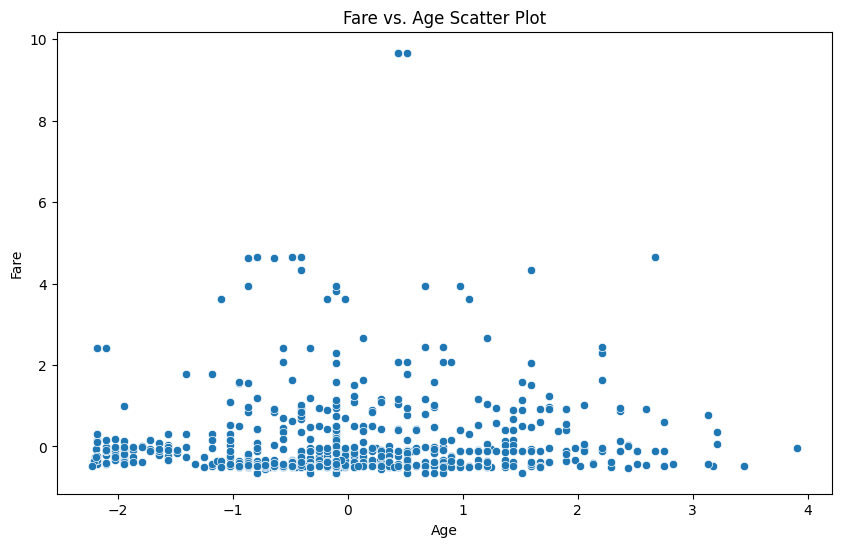

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Fare')
plt.title('Fare vs. Age Scatter Plot')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

# Summary of the Notebook

This notebook performs an exploratory data analysis and builds a predictive model for the Titanic dataset.

## Data Loading and Initial Exploration

*   The dataset was loaded from a CSV file into a pandas DataFrame.
*   Initial inspection included viewing the first few rows, checking for missing values, and examining descriptive statistics.

## Data Cleaning and Preprocessing

*   Missing values in the 'Age' column were imputed with the median age.
*   Rows with missing values in the 'Embarked' column were dropped.
*   The 'Cabin' column was dropped due to a high number of missing values.

## Exploratory Data Analysis

*   Value counts for 'Sex', 'Pclass', and 'Survived' were examined.
*   Count plots were generated to visualize the distribution of 'Survived' and the survival rates by 'Sex' and 'Pclass'.
*   A histogram was created to visualize the distribution of 'Age'.
*   A correlation heatmap was generated to show the relationships between numerical features and 'Survived'.
*   Survival percentages by sex and passenger class were calculated and displayed.
*   The age distribution of survivors was visualized with a histogram.
*   The relationship between age and survival by passenger class was visualized with a violin plot.
*   A scatter plot of 'Fare' vs 'Age' was generated.

## Feature Engineering

*   New features 'FamilySize' and 'IsAlone' were created from 'SibSp' and 'Parch'.
*   A 'Title' feature was extracted from the 'Name' column and rare titles were grouped.

## Feature Encoding and Scaling

*   Categorical features 'Sex' and 'Embarked' were converted into numerical format using one-hot encoding.
*   Numerical features 'Age', 'SibSp', 'Parch', 'Fare', and 'FamilySize' were scaled using StandardScaler.

## Model Selection and Training

*   The data was split into features (X) and target variable (y), and then into training and testing sets.
*   A Logistic Regression model was trained on the training data.
*   The model's performance was evaluated using accuracy, precision, recall, and F1-score on the test set.

## Conclusion

The notebook demonstrates a typical workflow for analyzing a dataset and building a classification model. The Logistic Regression model achieved reasonable performance metrics on the test set. Further improvements could involve exploring other models, hyperparameter tuning, and more advanced feature engineering techniques.